In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import random
from bct.utils.other import threshold_proportional, normalize
from small_world_propensity import SWP, characteristic_path_length, clustering_coefficient_bct
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import igraph as ig
from scipy.stats import spearmanr, pearsonr
from multiscale_backbone import disparity_filter, disparity_filter_alpha_cut

In [2]:
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')

In [2]:
spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
# List of subs
with open('/home/gbz6qn/Documents/research/code/coupling/compute_gca/subs.txt', 'r') as f:
    lines = f.read()
    subs = lines.split('\n')[:-1]
subs = sorted(subs)

In [5]:
t = threshold_proportional(np.abs(fc), 0.092)
G = nx.Graph(t)
c = nx.community.greedy_modularity_communities(G, weight='weight')
m = nx.community.modularity(G, c, weight='weight')
print(m)

0.3045673684342023


In [3]:
# Load in all subjects into stacked array
all_subs = []
for sub in subs:
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    fc_raw = np.load(fc_path)
    fc = np.abs(fc_raw)
    all_subs.append(fc)
stacked = np.stack(all_subs)

## No thresholding

In [4]:
swp = []
delta_C = []
delta_L = []
for i in range(len(stacked)):
    arr = stacked[i]
    swp_i, delta_C_i, delta_L_i = SWP(arr)
    swp.append(swp_i)
    delta_C.append(delta_C_i)
    delta_L.append(delta_L_i)

mean_swp = np.mean(swp)
mean_delta_C = np.mean(delta_C)
mean_delta_L = np.mean(delta_L)
print(f'SWP: {mean_swp}, delta_C: {mean_delta_C}, delta_L: {mean_delta_L}')

SWP: 0.5310280048874264, delta_C: 0.0, delta_L: 0.6632265558613705


In [5]:
means = []
for i in range(len(stacked)):
    arr = stacked[i]
    upper_tri = arr[np.triu_indices_from(arr, k=1)]
    connectivity = upper_tri[upper_tri > 0].mean()
    means.append(connectivity)

In [85]:
pearsonr(means, swp)

PearsonRResult(statistic=np.float64(-0.9340117484399088), pvalue=np.float64(3.1091785045558524e-148))

In [62]:
spearmanr(means, swp)

SignificanceResult(statistic=np.float64(-0.9442953858355592), pvalue=np.float64(6.837535783431903e-160))

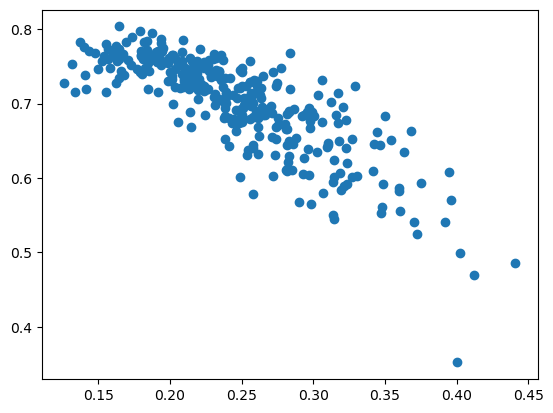

In [31]:
plt.scatter(means_sparser, SWP_sparser)

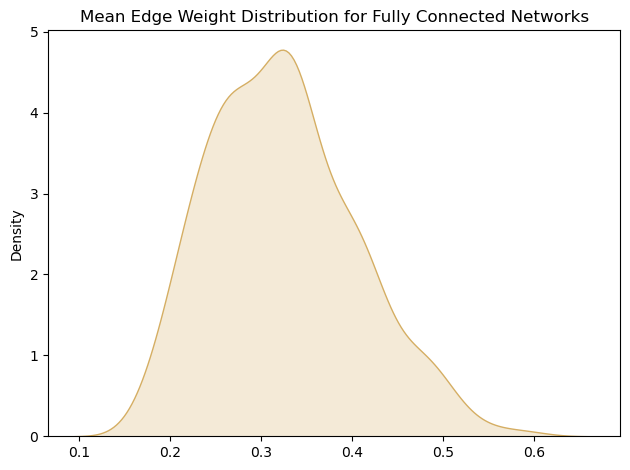

In [9]:
fig, ax = plt.subplots()
sns.kdeplot(means, color='#D5AE63', fill=True)
#ax.axvline(x=np.mean(means), color='#D5AE63')
plt.title('Mean Edge Weight Distribution for Fully Connected Networks')
plt.tight_layout()
plt.show()

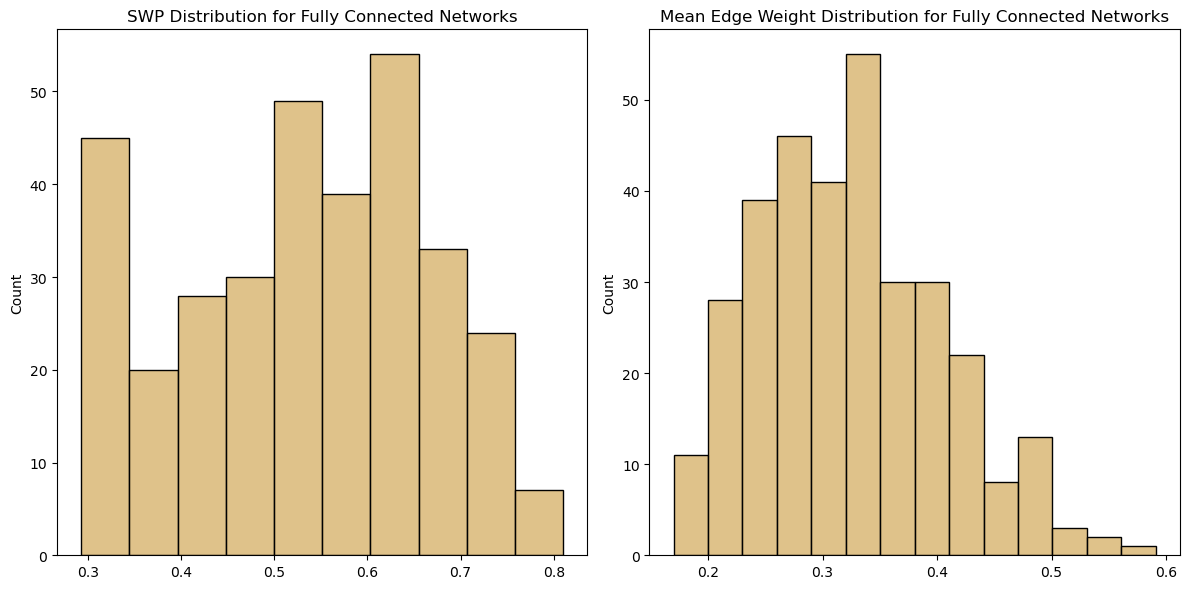

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.histplot(swp, color='#D5AE63', fill=True, ax=axes[0])
axes[0].set_title('SWP Distribution for Fully Connected Networks')

sns.histplot(means, color='#D5AE63', fill=True, ax=axes[1])
axes[1].set_title('Mean Edge Weight Distribution for Fully Connected Networks')

plt.tight_layout()
plt.savefig('full_connected_network_distributions.png', dpi=200)
plt.show()

## Thresholding by only retaining edges that also exist in the structural connectivity matrix

In [6]:
all_subs_sparser = []
for sub in subs:
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    sc_path = os.path.join(sc_dir, f'sub-{sub}_parc-shen268_tract-prob_sc.npy')
    
    fc_raw = np.load(fc_path)
    fc = np.abs(fc_raw)

    sc = np.load(sc_path)

    sparser = fc*(sc!=0)
    all_subs_sparser.append(sparser)
sparser = np.stack(all_subs_sparser)

In [7]:
SWP_sparser = []
delta_C_sparser = []
delta_L_sparser = []

for i in range(len(sparser)):
    adj = sparser[i]
    swp_i, delta_C_i, delta_L_i = SWP(adj)
    SWP_sparser.append(swp_i)
    delta_C_sparser.append(delta_C_i)
    delta_L_sparser.append(delta_L_i)

mean_swp = np.mean(SWP_sparser)
mean_delta_C = np.mean(delta_C_sparser)
mean_delta_L = np.mean(delta_L_sparser)
print(f'SWP: {mean_swp:.3f}, delta_C: {mean_delta_C:.3f}, delta_L: {mean_delta_L}')

SWP: 0.702, delta_C: 0.053, delta_L: 0.4069470570064112


In [8]:
means_sparser = []
for i in range(len(sparser)):
    arr = sparser[i]
    upper_tri = arr[np.triu_indices_from(arr, k=1)]
    connectivity = upper_tri[upper_tri > 0].mean()
    means_sparser.append(connectivity)

In [79]:
pearsonr(means_sparser, SWP_sparser)

PearsonRResult(statistic=np.float64(-0.7856718409604304), pvalue=np.float64(3.542442508279159e-70))

In [90]:
spearmanr(means_sparser, SWP_sparser)

SignificanceResult(statistic=np.float64(-0.8030809615915999), pvalue=np.float64(1.6344845556675258e-75))

In [9]:
results_sparser = {'swp': SWP_sparser, 'connectivity': means_sparser}
results_fc = {'swp': swp, 'connectivity': means}

In [10]:
df_fc = pd.long_dataframe = pd.DataFrame(results_fc)
df_fc['Method'] = 'No thresholding'
df_sparser = pd.long_dataframe = pd.DataFrame(results_sparser)
df_sparser['Method'] = 'Matched w/structural'

df = pd.concat([df_fc, df_sparser], axis=0)

In [66]:
df.head()

,swp,connectivity,Method
0,0.629400,0.137202,No thresholding
1,0.546030,0.161977,No thresholding
2,0.292893,0.232791,No thresholding
3,0.545125,0.167911,No thresholding
4,0.580551,0.155035,No thresholding


In [11]:
rows = []
for metric, values in results_fc.items():
    for value in values:
        rows.append({'metric': metric, 'value': value})
df_fc = pd.long_dataframe = pd.DataFrame(rows)
df_fc['Method'] = 'No thresholding'

rows = []
for metric, values in results_sparser.items():
    for value in values:
        rows.append({'metric': metric, 'value': value})
df_sparser = pd.long_dataframe = pd.DataFrame(rows)
df_sparser['Method'] = 'Matched w/structural'

df = pd.concat([df_fc, df_sparser], axis=0)
df.head()

,metric,value,Method
0,swp,0.629436,No thresholding
1,swp,0.546242,No thresholding
2,swp,0.292893,No thresholding
3,swp,0.545176,No thresholding
4,swp,0.580388,No thresholding


In [12]:
palette = sns.color_palette(["#D5AE63", "#6E6C81"])
palette

[(0.8352941176470589, 0.6823529411764706, 0.38823529411764707),
 (0.43137254901960786, 0.4235294117647059, 0.5058823529411764)]

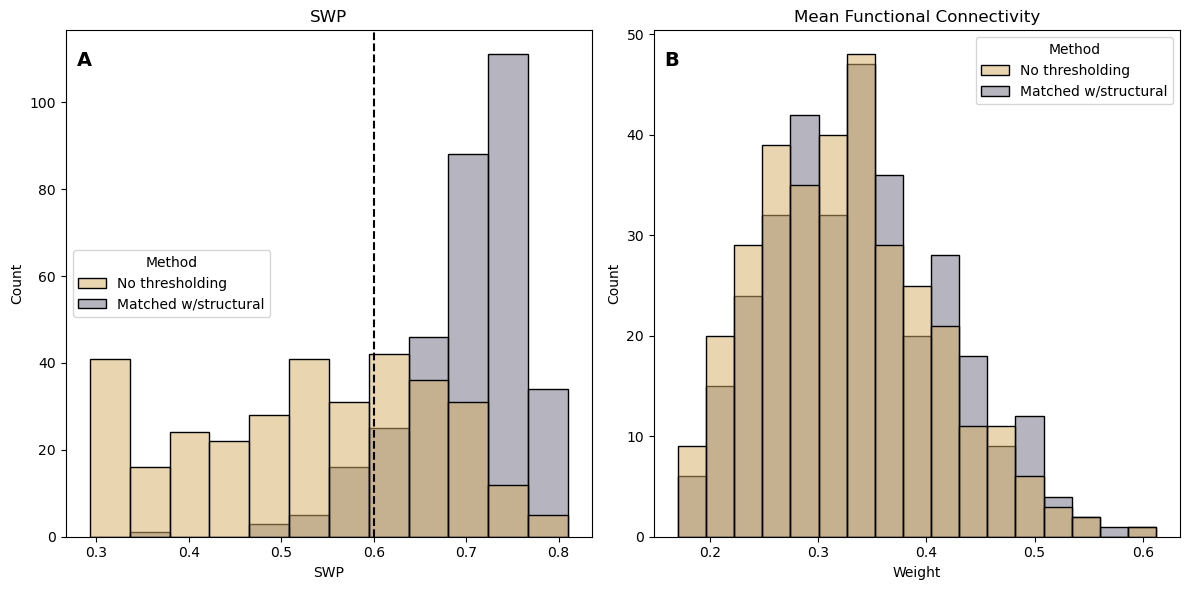

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(data=df[df['metric'] == 'swp'], x='value', stat='count',
             hue='Method', palette=palette, ax=axes[0])
axes[0].axvline(x=0.6, color='black', linestyle='--', label='Small-World Threshold')
axes[0].set_title('SWP')
axes[0].set_xlabel('SWP')

sns.histplot(data=df[df['metric'] == 'connectivity'], x='value', stat='count',
             hue='Method', palette=palette, ax=axes[1])
axes[1].set_title('Mean Functional Connectivity')
axes[1].set_xlabel('Weight')

for ax, label in zip(axes.flat, 'AB'):
    ax.annotate(label, xy=(0.02, 0.96), xycoords='axes fraction',
                fontsize=14, fontweight='bold', va='top')
#plt.suptitle('Distributions of SWP and Mean Functional Connectivity', fontsize=14)
plt.tight_layout()
plt.savefig('swp_connectivity_dist_fc_struc.png')
plt.show()

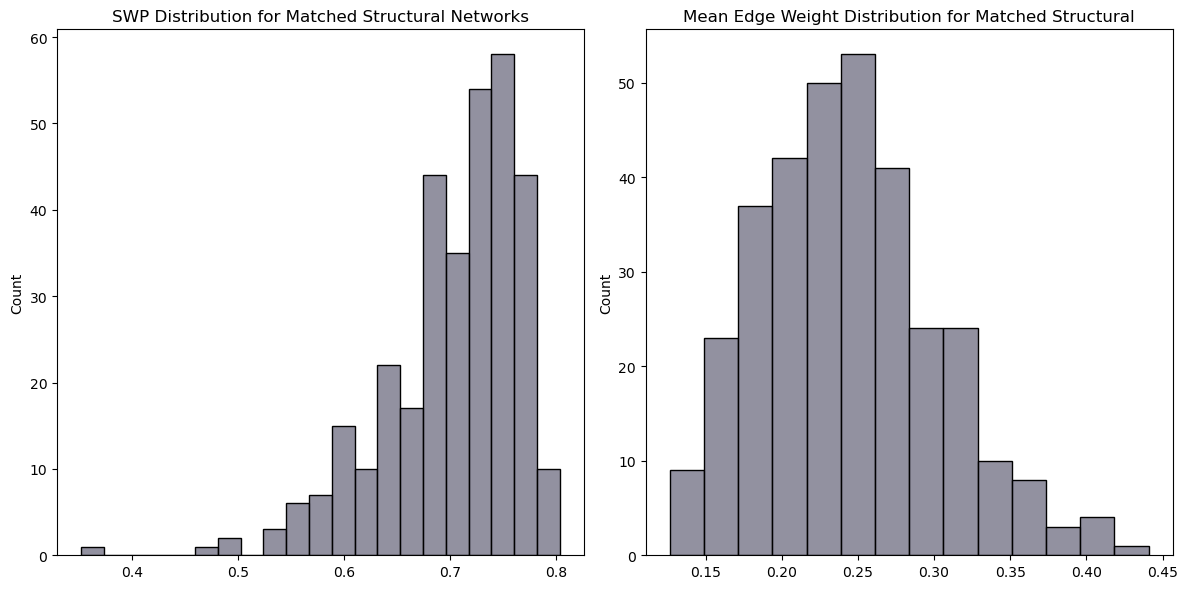

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.histplot(SWP_sparser, color="#6E6C81", fill=True, ax=axes[0])
axes[0].set_title('SWP Distribution for Matched Structural Networks')

sns.histplot(means_sparser, color="#6E6C81", fill=True, ax=axes[1])
axes[1].set_title('Mean Edge Weight Distribution for Matched Structural')

plt.tight_layout()
plt.savefig('matched_structural_network_distributions.png', dpi=200)
plt.show()

## Threshold using proportional thresholding at various levels
I want to examine how clustering, path length, and SWP change at the various levels

In [8]:
def consensus_threshold(matrices, rho, x_pct) -> np.ndarray:
    """
    Consensus thresholding on a stack of adjacency matrices.

    Parameters
    ----------
    matrices : np.ndarray, shape (n_subjects, n_nodes, n_nodes)
        Stack of weighted adjacency matrices with edge weights in [0, 1].
    rho : float
        Minimum edge weight to count as "present" in a subject.
    x_pct : float
        Minimum fraction of subjects (in [0, 1]) that must have the edge
        above rho for it to be retained. E.g. 0.5 = 50%.

    Returns
    -------
    consensus_mask : np.ndarray, shape (n_nodes, n_nodes)
        Binary consensus mask (1 = retained, 0 = eliminated).
    mean_matrix_threshold : np.ndarray, shape (n_nodes, n_nodes)
        Mean weight matrix masked by consensus (useful as a weighted output).
    """
    n_subjects = matrices.shape[0]

    # Step 1: binarize each subject's matrix at threshold rho
    # (n_subjects, n_nodes, n_nodes)
    present = (matrices >= rho)

    # Step 2: fraction of subjects with edge above rho
    prevalence = present.mean(axis=0)

    # Step 3: retain edges meeting the consensus criterion
    consensus_mask = (prevalence >= x_pct)

    # Step 4: apply mask to mean weights (common output format)
    mean_matrix = matrices.mean(axis=0)
    mean_matrix_thresholded = mean_matrix * consensus_mask

    return consensus_mask, mean_matrix_thresholded

In [44]:
mask, thresholded = consensus_threshold(stacked, 0.2, 0.5)

In [45]:
nx.is_connected(nx.Graph(thresholded))

False

<Axes: >

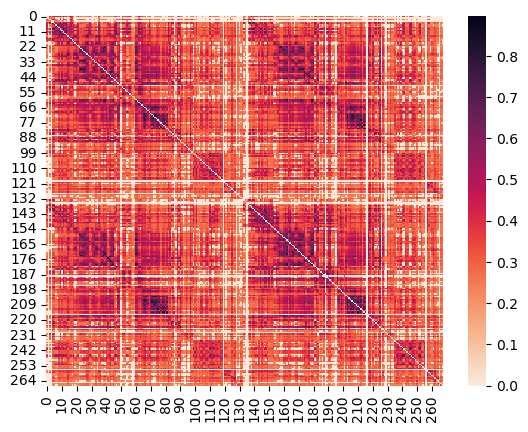

In [46]:
sns.heatmap(thresholded, cmap='rocket_r')

In [4]:
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results = {t: {'clustering': [], 'path_length': [], 'swp': []} for t in thresholds}
# Loop over each threshold
for _, threshold in tqdm(enumerate(thresholds)):
    # Loop over each subject
    for i in range(stacked.shape[0]):
        # Threshold at current level
        adj = np.where(stacked[i] >= threshold, stacked[i], 0)
        c = clustering_coefficient_bct(adj)
        l = characteristic_path_length(adj)
        swp, _, _ = SWP(adj)
        results[threshold]['clustering'].append(c)
        results[threshold]['path_length'].append(l)
        results[threshold]['swp'].append(swp)


0it [01:37, ?it/s]


KeyboardInterrupt: 

In [26]:
G = nx.Graph(np.abs(fc))
alpha = 0.1
G = disparity_filter(G)
G2 = nx.Graph([(u, v, d) for u, v, d in G.edges(data=True) if d['alpha'] < alpha])
print('alpha = %s' % alpha)
print('original: nodes = %s, edges = %s' % (G.number_of_nodes(), G.number_of_edges()))
print('backbone: nodes = %s, edges = %s' % (G2.number_of_nodes(), G2.number_of_edges()))
print(nx.is_connected(G2))

alpha = 0.1
original: nodes = 268, edges = 35778
backbone: nodes = 240, edges = 718
True


In [6]:
for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    G = disparity_filter(G)
    G2 = disparity_filter_alpha_cut(G, alpha_t=t)
    adj = nx.to_numpy_array(G2)
    density = nx.density(G2)
    N = len(adj)
    edges=G2.number_of_edges()
    print(f't={t}: density={density}, N={N}, edges={edges}, connected={nx.is_connected(G2)}')

t=0.05: density=0.02773109243697479, N=85, edges=99, connected=False
t=0.1: density=0.02503486750348675, N=240, edges=718, connected=True
t=0.15: density=0.0648813043845569, N=267, edges=2304, connected=True
t=0.2: density=0.13941528313488735, N=268, edges=4988, connected=True
t=0.25: density=0.23833081782100732, N=268, edges=8527, connected=True
t=0.3: density=0.3456313935938286, N=268, edges=12366, connected=True
t=0.35: density=0.4461400860864218, N=268, edges=15962, connected=True
t=0.4: density=0.5398289451618313, N=268, edges=19314, connected=True
t=0.45: density=0.620828442059366, N=268, edges=22212, connected=True
t=0.5: density=0.6912627871876572, N=268, edges=24732, connected=True


In [43]:
print(f'density={nx.density(nx.Graph(np.abs(fc)))}, N={len(fc)}, edges={nx.Graph(np.abs(fc)).number_of_edges()}')

density=1.0, N=268, edges=35778


In [8]:
G = nx.Graph(np.abs(fc))
G2 = disparity_filter(G)
G_disp = disparity_filter_alpha_cut(G2, alpha_t=0.01)
adj = nx.to_numpy_array(G_disp)
c = clustering_coefficient_bct(adj)

In [9]:
c

np.float64(0.5089315544853693)

In [10]:
nx.is_connected(G_disp)

False

In [11]:
nx.density(G_disp)

0.4